# AlphaLens Chronological Baselines

This notebook establishes the hurdle that a more complex model must beat. It compares zero excess return, the historical training mean, and regularized linear regression.

The split is chronological:

- **Train:** observations whose complete target window ends before July 2024;
- **Validation:** anchors from July 2024 through June 2025 whose targets end before July 2025;
- **Test:** anchors from July 2025 onward;
- **Purged:** labels crossing either boundary.

Ridge regularization is selected using validation MAE. The test period is evaluated only after that choice.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from pipelines.ml.baselines import (
    evaluate_predictions,
    run_baseline_experiment,
    validate_purged_split,
)
from pipelines.ml.features import build_event_feature_dataset

pd.set_option('display.max_columns', 40)
sns.set_theme(style='whitegrid', context='notebook')

## Build features and run the experiment

In [2]:
dataset = build_event_feature_dataset(horizon=30, include_topics=True)
experiment = run_baseline_experiment(
    dataset,
    validation_start='2024-07-01',
    test_start='2025-07-01',
)
split_checks = validate_purged_split(experiment.split)
split_checks

{'train_rows': 407,
 'validation_rows': 152,
 'test_rows': 151,
 'purged_rows': 11,
 'overlapping_event_keys': 0,
 'train_targets_cross_validation': 0,
 'validation_targets_cross_test': 0}

## Purged time split

Purging removes an observation when its future-return window extends into the next fold. This prevents training labels from containing price information that belongs to validation or test time.

In [3]:
split_summary = pd.DataFrame([
    {
        'split': name,
        'rows': len(frame),
        'first_feature_date': frame['feature_as_of_date'].min(),
        'last_feature_date': frame['feature_as_of_date'].max(),
        'last_target_date': frame['target_trading_date'].max(),
    }
    for name, frame in [
        ('train', experiment.split.train),
        ('validation', experiment.split.validation),
        ('test', experiment.split.test),
        ('purged', experiment.split.purged),
    ]
])
display(split_summary)

,split,rows,first_feature_date,last_feature_date,last_target_date
0,train,407,2021-08-25,2024-05-10,2024-06-25
1,validation,152,2024-07-15,2025-05-09,2025-06-24
2,test,151,2025-07-16,2026-06-04,2026-07-20
3,purged,11,2024-05-17,2025-06-09,2025-07-23


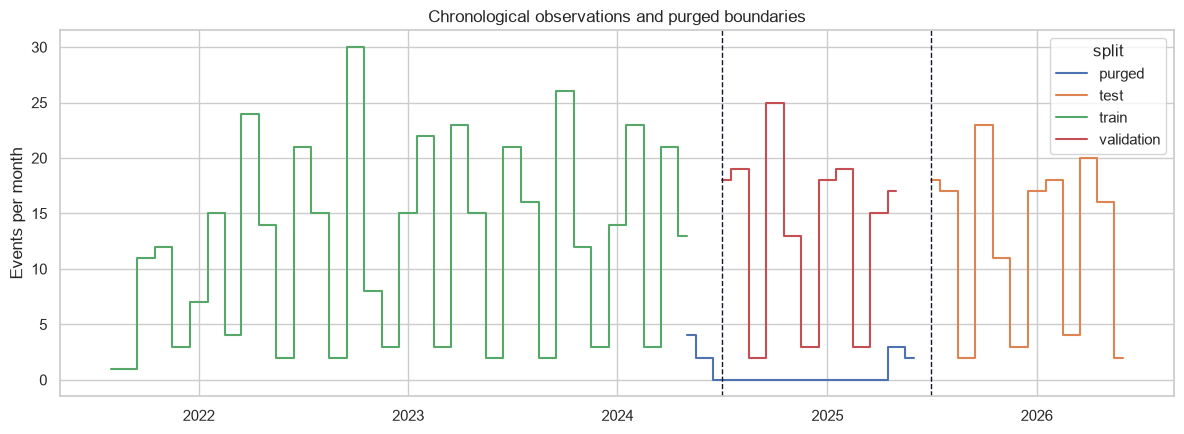

In [4]:
timeline_parts = []
for name, frame in [
    ('train', experiment.split.train),
    ('validation', experiment.split.validation),
    ('test', experiment.split.test),
    ('purged', experiment.split.purged),
]:
    part = frame[['feature_as_of_date']].copy()
    part['split'] = name
    part['count'] = 1
    timeline_parts.append(part)
timeline = pd.concat(timeline_parts).set_index('feature_as_of_date')
monthly = timeline.groupby('split')['count'].resample('MS').sum().reset_index()
fig, ax = plt.subplots(figsize=(12, 4.5))
sns.lineplot(data=monthly, x='feature_as_of_date', y='count', hue='split', drawstyle='steps-mid', ax=ax)
ax.axvline(pd.Timestamp('2024-07-01'), color='#111827', linestyle='--', linewidth=1)
ax.axvline(pd.Timestamp('2025-07-01'), color='#111827', linestyle='--', linewidth=1)
ax.set(title='Chronological observations and purged boundaries', xlabel='', ylabel='Events per month')
plt.tight_layout()
plt.show()

## Validation model selection

The Ridge alpha is selected by validation MAE, with RMSE as the tie-breaker. Zero-return and historical-mean predictions are reference hurdles, not tuning candidates.

In [5]:
metric_formats = {
    'mae': '{:.2%}', 'rmse': '{:.2%}', 'r2': '{:.3f}',
    'directional_accuracy': '{:.1%}', 'pearson': '{:.3f}',
    'spearman_ic': '{:.3f}', 'prediction_mean': '{:.2%}',
    'prediction_std': '{:.2%}', 'actual_mean': '{:.2%}',
}
print(f'Selected Ridge alpha: {experiment.selected_alpha:g}')
display(experiment.validation_metrics.style.format(metric_formats))

Selected Ridge alpha: 100


,split,model,rows,mae,rmse,r2,directional_accuracy,pearson,spearman_ic,prediction_mean,prediction_std,actual_mean
0,validation,zero_excess,152,7.66%,10.87%,-0.011,39.5%,nan,nan,0.00%,0.00%,1.11%
1,validation,historical_mean,152,7.66%,10.87%,-0.011,39.5%,nan,nan,-0.00%,0.00%,1.11%
2,validation,ridge_alpha_100,152,7.91%,11.15%,-0.063,50.7%,-0.000,0.047,-0.62%,2.08%,1.11%
3,validation,ridge_alpha_10,152,8.69%,11.99%,-0.229,43.4%,-0.093,-0.049,-1.67%,3.48%,1.11%
4,validation,ridge_alpha_1,152,9.21%,12.60%,-0.356,42.8%,-0.127,-0.106,-2.20%,4.34%,1.11%
5,validation,ridge_alpha_0.1,152,9.30%,12.71%,-0.380,42.1%,-0.131,-0.116,-2.29%,4.49%,1.11%
6,validation,ridge_alpha_0.01,152,9.31%,12.72%,-0.383,42.1%,-0.132,-0.117,-2.29%,4.51%,1.11%


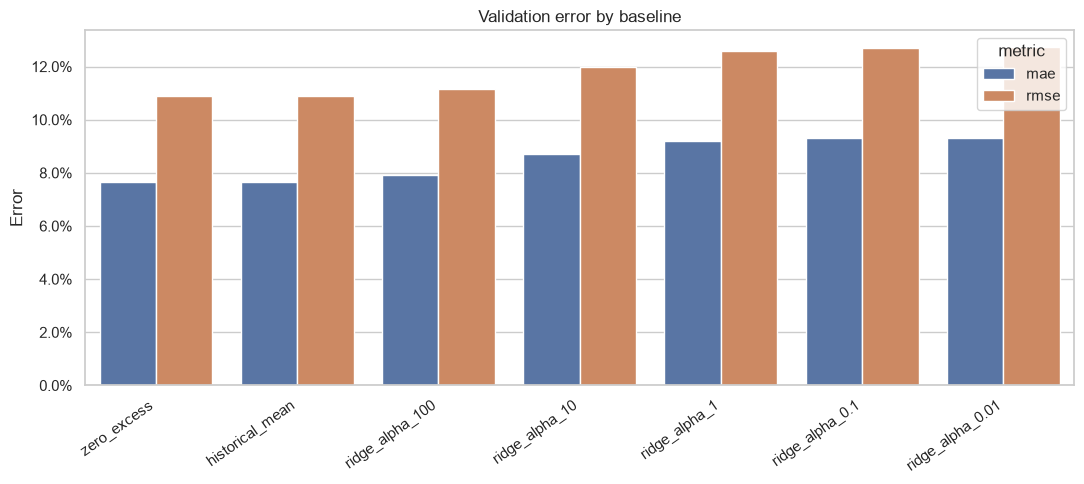

In [6]:
validation_plot = experiment.validation_metrics.melt(
    id_vars='model', value_vars=['mae', 'rmse'],
    var_name='metric', value_name='error'
)
fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=validation_plot, x='model', y='error', hue='metric', ax=ax)
ax.set(title='Validation error by baseline', xlabel='', ylabel='Error')
ax.yaxis.set_major_formatter(lambda value, _: f'{value:.1%}')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

## Untouched test-period results

The selected Ridge model is refit on train plus validation, then evaluated once against the later test period. A complex model must improve on the best simple test hurdle to justify deployment.

In [7]:
display(experiment.test_metrics.style.format(metric_formats))

,split,model,rows,mae,rmse,r2,directional_accuracy,pearson,spearman_ic,prediction_mean,prediction_std,actual_mean
0,test,historical_mean,151,6.27%,8.27%,-0.000,53.0%,nan,nan,0.30%,0.00%,0.25%
1,test,zero_excess,151,6.28%,8.27%,-0.001,47.0%,nan,nan,0.00%,0.00%,0.25%
2,test,ridge_alpha_100,151,6.73%,8.89%,-0.156,43.7%,-0.091,-0.193,0.44%,2.59%,0.25%


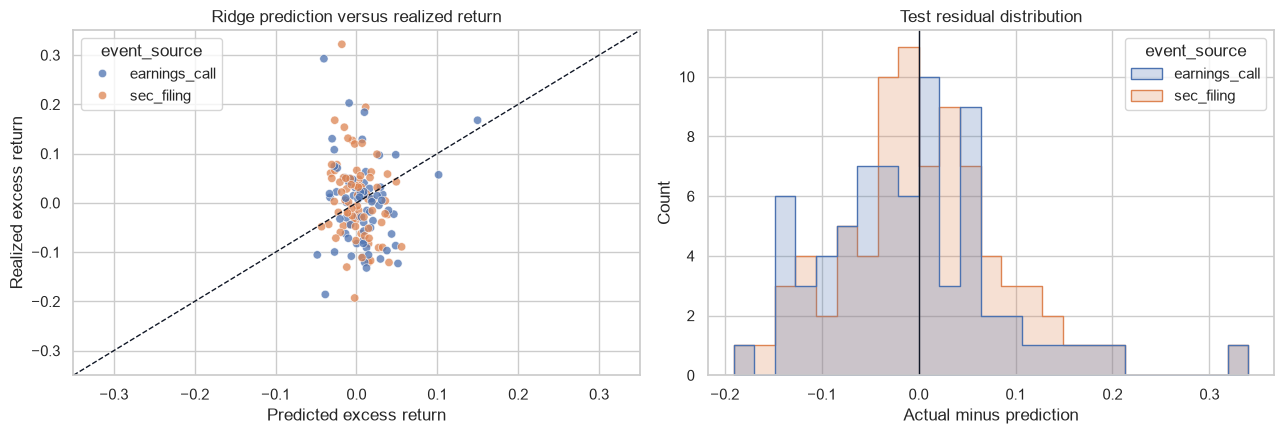

In [8]:
ridge_name = f'ridge_alpha_{experiment.selected_alpha:g}'
ridge_predictions = experiment.test_predictions.query('model == @ridge_name').copy()
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.scatterplot(
    data=ridge_predictions, x='prediction', y='excess_return_30d',
    hue='event_source', alpha=0.75, ax=axes[0]
)
limits = [-0.35, 0.35]
axes[0].plot(limits, limits, color='#111827', linestyle='--', linewidth=1)
axes[0].set(xlim=limits, ylim=limits, title='Ridge prediction versus realized return', xlabel='Predicted excess return', ylabel='Realized excess return')
sns.histplot(data=ridge_predictions, x='residual', hue='event_source', bins=25, element='step', ax=axes[1])
axes[1].axvline(0, color='#111827', linewidth=1)
axes[1].set(title='Test residual distribution', xlabel='Actual minus prediction')
plt.tight_layout()
plt.show()

## Test diagnostics by event source

Aggregate metrics can hide a model that works for calls but fails for filings, or vice versa.

In [9]:
segment_rows = []
for source, group in ridge_predictions.groupby('event_source'):
    row = evaluate_predictions(
        group['excess_return_30d'], group['prediction'],
        model_name=ridge_name, split_name=f'test_{source}'
    )
    segment_rows.append(row)
display(pd.DataFrame(segment_rows).style.format(metric_formats))

,split,model,rows,mae,rmse,r2,directional_accuracy,pearson,spearman_ic,prediction_mean,prediction_std,actual_mean
0,test_earnings_call,ridge_alpha_100,71,6.90%,9.03%,-0.126,40.8%,0.020,-0.129,0.78%,3.06%,-0.13%
1,test_sec_filing,ridge_alpha_100,80,6.58%,8.77%,-0.190,46.2%,-0.239,-0.241,0.15%,2.05%,0.60%


## Standardized Ridge coefficients

Coefficients describe the fitted linear model, not causal effects. Large coefficients can also reflect correlated features or missingness indicators.

In [10]:
imputer = experiment.ridge_model.named_steps['imputer']
coefficient_names = imputer.get_feature_names_out(experiment.feature_columns)
coefficients = pd.Series(
    experiment.ridge_model.named_steps['model'].coef_,
    index=coefficient_names, name='standardized_coefficient'
)
display(coefficients.reindex(coefficients.abs().sort_values(ascending=False).index).head(20).to_frame())

,standardized_coefficient
momentum_5d,0.009191
sma_ratio_20d,0.008605
volume_ratio_20d,0.008546
topic_demand_consumer_sentiment,0.008140
missingindicator_topic_demand_consumer_sentiment,-0.007714
topic_guidance_outlook_share,-0.007479
missingindicator_momentum_126d,-0.007268
spy_momentum_63d,-0.006439
spy_volatility_21d,-0.006007
sentiment_change_from_prior,0.005778


## Decision for the next stage

The baseline result is the acceptance threshold, even when it is unimpressive. The next step is an XGBoost experiment with validation-only hyperparameter selection. It must beat the historical-mean test MAE and improve rank correlation without relying on the test set for tuning.